In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('titanic.csv',usecols=['survived','pclass','age','sibsp','parch','fare'])

In [3]:
df.sample(10)

,survived,pclass,age,sibsp,parch,fare
474,0,3,22.0,0,0,9.8375
303,1,2,NaN,0,0,12.3500
769,0,3,32.0,0,0,8.3625
634,0,3,9.0,3,2,27.9000
454,0,3,NaN,0,0,8.0500
592,0,3,47.0,0,0,7.2500
74,1,3,32.0,0,0,56.4958
452,0,1,30.0,0,0,27.7500
776,0,3,NaN,0,0,7.7500
729,0,3,25.0,1,0,7.9250


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   age       714 non-null    float64
 3   sibsp     891 non-null    int64  
 4   parch     891 non-null    int64  
 5   fare      891 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 41.9 KB


In [5]:
df=df.dropna()

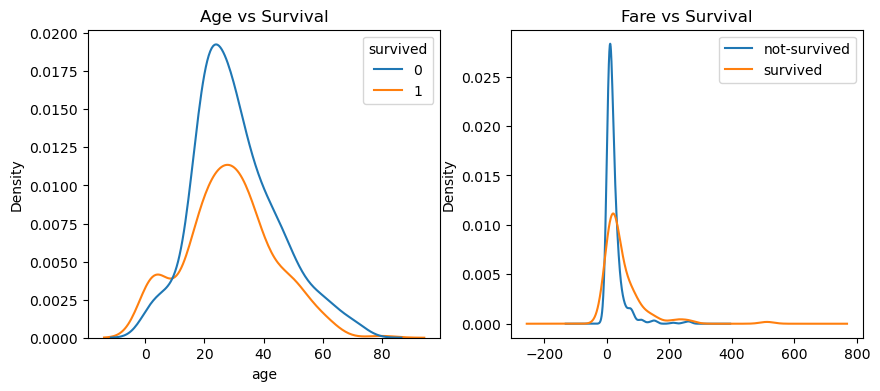

In [6]:
fig , ax = plt.subplots(1,2,figsize=(10,4))
sns.kdeplot(data=df,x='age',hue='survived',ax=ax[0])
ax[0].set_title('Age vs Survival')
df[df['survived']==0]['fare'].plot(kind='kde',ax=ax[1],label='not-survived')
df[df['survived']==1]['fare'].plot(kind='kde',ax=ax[1],label='survived')
ax[1].set_title('Fare vs Survival')
ax[1].legend()

<Axes: xlabel='age', ylabel='fare'>

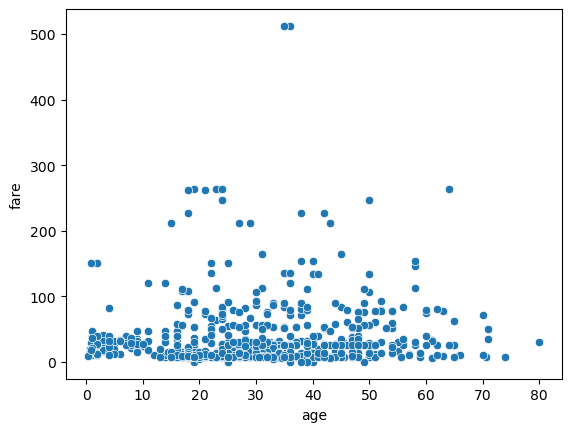

In [7]:

sns.scatterplot(data=df,x='age',y='fare')

In [8]:
print(df['age'].mean())
print(df['age'].std())
print(df['fare'].mean())
print(df['fare'].std())

29.69911764705882
14.526497332334044
34.694514005602244
52.9189295025436


In [9]:
from sklearn.model_selection import train_test_split;
x=df.drop(columns=['survived'])
y=df['survived']

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


In [11]:
from sklearn.linear_model import LogisticRegression

In [12]:
model=LogisticRegression()

In [13]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
from sklearn.metrics import accuracy_score

In [16]:
y_pred=model.predict(x_test)
acc=accuracy_score(y_test,y_pred)

In [17]:
acc

0.7069767441860465

### ab ham karenge MinMaxScaler

In [18]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
scalar=MinMaxScaler()

In [20]:
x_train_df=pd.DataFrame(scalar.fit_transform(x_train),columns=x_train.columns)
x_test_df=pd.DataFrame(scalar.transform(x_test),columns=x_test.columns)
x_train_df['age'].max()

1.0

Text(0.5, 1.0, 'After Standardization')

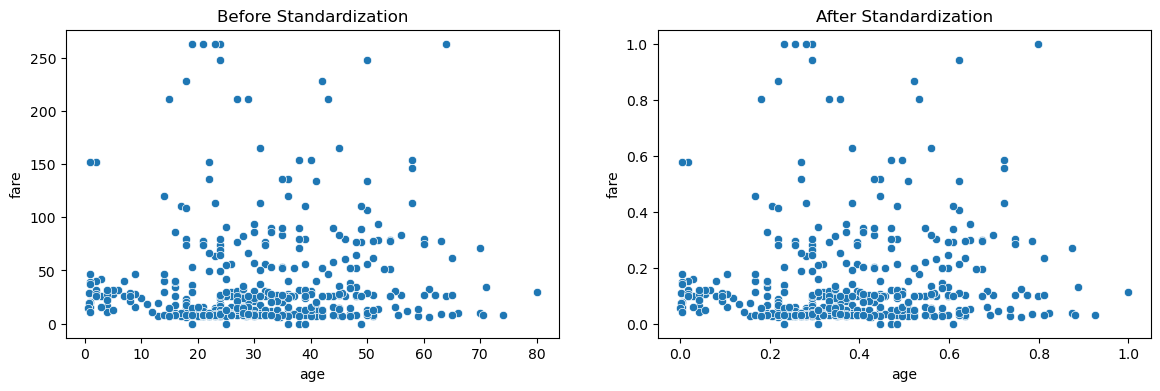

In [21]:
fig , ax = plt.subplots(1,2,figsize=(14,4))
sns.scatterplot(x='age',y='fare',data=x_train,ax=ax[0])
ax[0].set_title('Before Standardization')
sns.scatterplot(x='age',y='fare',data=x_train_df,ax=ax[1])
ax[1].set_title('After Standardization')

In [22]:
print(x_train_df['age'].mean())
print(x_train_df['age'].std())
print(x_train_df['fare'].mean())
print(x_train_df['fare'].std())

0.3741106314481983
0.18747640996502654
0.13342480245662428
0.1760055166316543


In [23]:
model2=LogisticRegression()
model2.fit(x_train_df,y_train)
y_pred2=model2.predict(x_test_df)
acc=accuracy_score(y_test,y_pred2)
acc
df

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
885,0,3,39.0,0,5,29.1250
886,0,2,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
889,1,1,26.0,0,0,30.0000


In [24]:
# coefficients compare karo
print(model.coef_)
print(model2.coef_)

[[-1.18115488 -0.04862058 -0.26368199  0.1473428   0.00239168]]
[[-2.00926179 -2.57045501 -0.66823978  0.53560763  0.56896007]]


### ab hoga bawaal

In [25]:
df['fare']=df['fare']*10000
df['age']=df['age']*1000000000

In [26]:
df.sample(10)

,survived,pclass,age,sibsp,parch,fare
379,0,3,1.900000e+10,0,0,77750.0
253,0,3,3.000000e+10,1,0,161000.0
874,1,2,2.800000e+10,1,0,240000.0
132,0,3,4.700000e+10,1,0,145000.0
556,1,1,4.800000e+10,1,0,396000.0
146,1,3,2.700000e+10,0,0,77958.0
696,0,3,4.400000e+10,0,0,80500.0
595,0,3,3.600000e+10,1,1,241500.0
88,1,1,2.300000e+10,3,2,2630000.0
811,0,3,3.900000e+10,0,0,241500.0


In [27]:
x=df.drop(columns=['survived'])
y=df['survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
x_train
model3=LogisticRegression()
model3.fit(x_train,y_train)
y_pred3=model3.predict(x_test)
acc=accuracy_score(y_test,y_pred3)
acc

0.6558139534883721

In [28]:
x_train_df=pd.DataFrame(scalar.fit_transform(x_train),columns=x_train.columns)
x_test_df=pd.DataFrame(scalar.transform(x_test),columns=x_test.columns)

In [29]:
model3=LogisticRegression()
model3.fit(x_train_df,y_train)
y_pred3=model3.predict(x_test_df)
acc=accuracy_score(y_test,y_pred3)
acc

0.7162790697674418

aao backhodi karte hai


In [30]:
df

,survived,pclass,age,sibsp,parch,fare
0,0,3,2.200000e+10,1,0,72500.0
1,1,1,3.800000e+10,1,0,712833.0
2,1,3,2.600000e+10,0,0,79250.0
3,1,1,3.500000e+10,1,0,531000.0
4,0,3,3.500000e+10,0,0,80500.0
...,...,...,...,...,...,...
885,0,3,3.900000e+10,0,5,291250.0
886,0,2,2.700000e+10,0,0,130000.0
887,1,1,1.900000e+10,0,0,300000.0
889,1,1,2.600000e+10,0,0,300000.0


In [34]:
df.iloc[0,2]=5

<Axes: xlabel='age', ylabel='Density'>

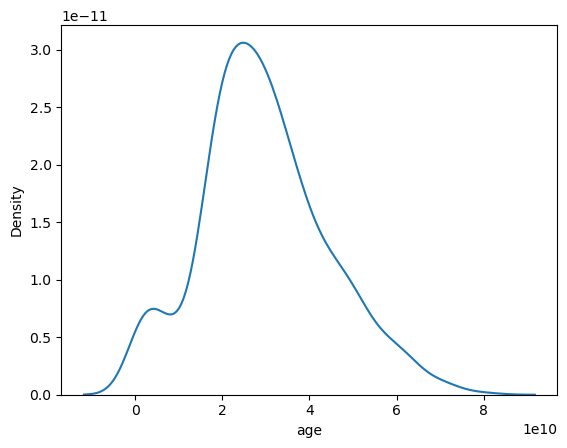

In [39]:
df['age']=df['age']/100000